In [1]:
import pandas as pd
import sqlite3

pd.set_option('display.max_columns', None)

print("setup works!")

setup works!


In [2]:
# Connect to SQLite database
conn = sqlite3.connect("../ecommerce.db") 

print("Connected to SQLite database")

Connected to SQLite database


In [3]:
# Load main Brazilian E-commerce CSVs
orders = pd.read_csv("../data/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")

print("CSV files loaded into pandas")

CSV files loaded into pandas


In [4]:
# Inspect first 5 rows of orders
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
# Push tables into SQLite database
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
customers.to_sql("customers", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)

print("All tables pushed to SQLite")

All tables pushed to SQLite


In [6]:
# Check number of rows for one table
pd.read_sql("SELECT COUNT(*) AS total_orders FROM orders;", conn)

,total_orders
0,99441


In [7]:
# Join Orders + Customers
query = """
SELECT o.order_id, c.customer_unique_id, o.order_purchase_timestamp
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
LIMIT 10;
"""
pd.read_sql(query, conn)

,order_id,customer_unique_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07-09 21:57:05
6,136cce7faa42fdb2cefd53fdc79a6098,36edbb3fb164b1f16485364b6fb04c73,2017-04-11 12:22:08
7,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,2017-05-16 13:10:30
8,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,2017-01-23 18:29:09
9,e69bfb5eb88e0ed6a785585b27e16dbf,299905e3934e9e181bfb2e164dd4b4f8,2017-07-29 11:55:02


In [8]:
# Check the tables exist in the database
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,orders
1,order_items
2,customers
3,payments
4,products


### High-Impact SQL Analysis

#### 📈 Monthly Revenue Trends

In [9]:
# Total revenue per month
query = """
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    SUM(oi.price) AS total_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY month
ORDER BY month;
"""
monthly_revenue = pd.read_sql(query, conn)
monthly_revenue

,month,total_revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


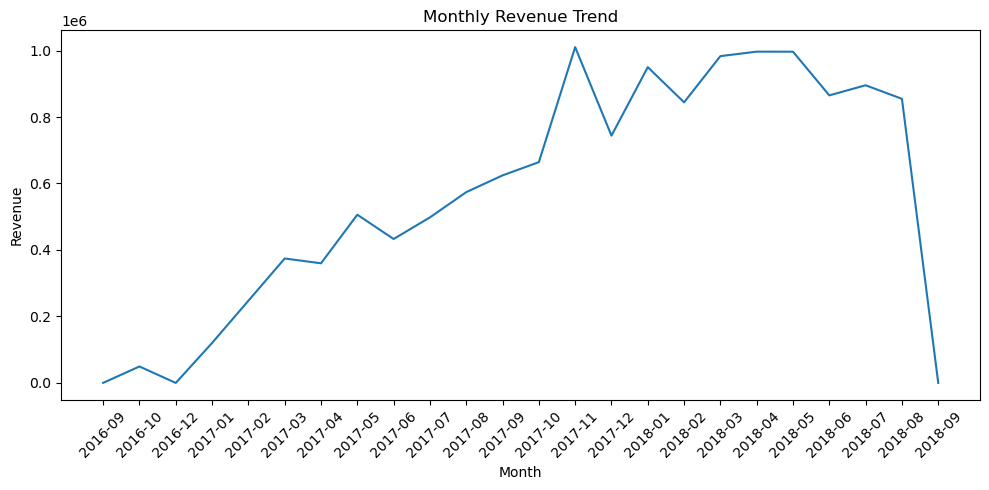

In [10]:
# Create the plot to see the monthly revenue trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['month'], monthly_revenue['total_revenue'])
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../images/monthly_revenue.png', dpi=300)
plt.show()

Business Insight: 
- Revenue increases gradually across 2017 and peaks in Novemer, which may be driven by seasonal promotions (e.g., Black Friday).
- In early 2018, revenue stays at a higher level, indicating sustained growth.
- The final sharp decline appears to reflect incomplete monthly data rather than a true business downturn.

#### 💰 Average Order Value (AOV)

In [11]:
# Calculate Average Order Value
query = """
SELECT 
    o.order_id,
    SUM(oi.price) AS order_total
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY o.order_id;
"""
orders_total = pd.read_sql(query, conn)
aov = orders_total['order_total'].mean()

In [12]:
print(f"Average Order Value (AOV): ${aov:.2f}")

Average Order Value (AOV): $137.75


Business Insight: This provides a baseline for evaluating pricing strategy, bundling opportunities, and customer acquisition costs.

#### 🔁 Repeat Customers

In [13]:
# Count number of orders per customer
query = """
SELECT 
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS num_orders
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
ORDER BY num_orders DESC;
"""
customer_orders = pd.read_sql(query, conn)

# Repeat purchase rate
repeat_rate = (customer_orders['num_orders'] > 1).mean()
customer_orders.head(10)

,customer_unique_id,num_orders
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,ca77025e7201e3b30c44b472ff346268,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,1b6c7548a2a1f9037c1fd3ddfed95f33,7
5,f0e310a6839dce9de1638e0fe5ab282a,6
6,de34b16117594161a6a89c50b289d35a,6
7,dc813062e0fc23409cd255f7f53c7074,6
8,63cfc61cee11cbe306bff5857d00bfe4,6
9,47c1a3033b8b77b3ab6e109eb4d5fdf3,6


In [14]:
print(f"Repeat Purchase Rate: {repeat_rate*100:.2f}%")

Repeat Purchase Rate: 3.12%


Business Insight: This suggests limited customer retention and a strong dependence on acquiring new customers to drive revenue growth.

#### 🏆 Top Product Categories by Revenue

In [15]:
# Revenue by product category
query = """
SELECT 
    p.product_category_name,
    SUM(oi.price) AS revenue
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY revenue DESC
LIMIT 10;
"""
top_categories = pd.read_sql(query, conn)
top_categories

,product_category_name,revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


Note: Product category names were originally in Portuguese. 
They have been translated into English in the plot analysis for clarity.

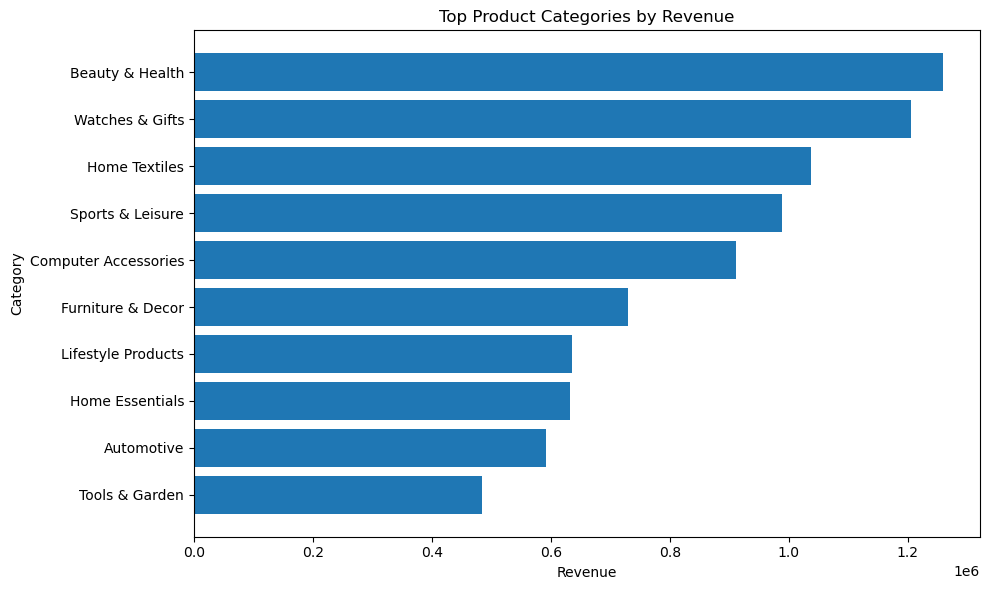

In [16]:
# Plot for top product category by revenue

# Translation for categories name
translation = {
    "beleza_saude": "Beauty & Health",
    "relogios_presentes": "Watches & Gifts",
    "cama_mesa_banho": "Home Textiles",
    "esporte_lazer": "Sports & Leisure",
    "informatica_acessorios": "Computer Accessories",
    "moveis_decoracao": "Furniture & Decor",
    "cool_stuff": "Lifestyle Products",
    "utilidades_domesticas": "Home Essentials",
    "automotivo": "Automotive",
    "ferramentas_jardim": "Tools & Garden"
}

top_categories["category_en"] = top_categories["product_category_name"].map(translation)
plt.figure(figsize=(10,6))
plt.barh(top_categories['category_en'], top_categories['revenue'])
plt.gca().invert_yaxis()
plt.title('Top Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('../images/top_categories.png', dpi=300)
plt.show()

Business Insight: Revenue is concentrated in beauty, gifts, and home-related categories, which appear to drive the majority of sales. 
This suggests that customer demand is strongest in lifestyle-oriented products, highlighting these segments as key revenue engines for the business.

#### 💳 Revenue by Payment Type

In [17]:
# Revenue by payment type
query = """
SELECT 
    payment_type,
    SUM(payment_value) AS revenue
FROM payments
GROUP BY payment_type
ORDER BY revenue DESC;
"""
payment_revenue = pd.read_sql(query, conn)
payment_revenue

,payment_type,revenue
0,credit_card,12542084.19
1,boleto,2869361.27
2,voucher,379436.87
3,debit_card,217989.79
4,not_defined,0.00


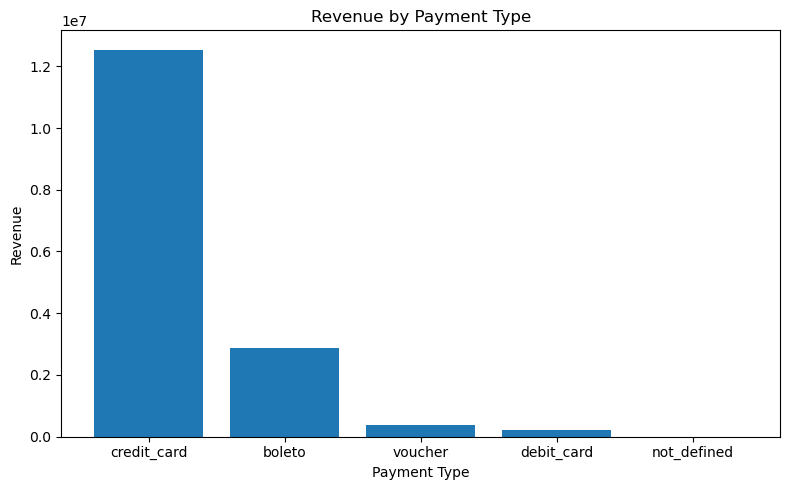

In [18]:
# Plot for revenue by payment type
plt.figure(figsize=(8,5))
plt.bar(payment_revenue['payment_type'], payment_revenue['revenue'])
plt.title('Revenue by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('../images/revenue_by_payment_type.png', dpi=300)
plt.show()

Business Insight: Revenue is heavily dominated by credit card payments, with boleto (a common Brazilian bank slip payment method) as a distant second. Voucher and debit card contribute only a small portion of total revenue.

#### 🌟 Top 10 Customers by Revenue

In [19]:
# Get top 10 customers spent the most
query = """
SELECT 
    c.customer_unique_id,
    SUM(oi.price) AS total_spent
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY c.customer_unique_id
ORDER BY total_spent DESC
LIMIT 10;
"""
top_customers = pd.read_sql(query, conn)
top_customers

,customer_unique_id,total_spent
0,0a0a92112bd4c708ca5fde585afaa872,13440.0
1,da122df9eeddfedc1dc1f5349a1a690c,7388.0
2,763c8b1c9c68a0229c42c9fc6f662b93,7160.0
3,dc4802a71eae9be1dd28f5d788ceb526,6735.0
4,459bef486812aa25204be022145caa62,6729.0
5,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0
6,4007669dec559734d6f53e029e360987,5934.6
7,eebb5dda148d3893cdaf5b5ca3040ccb,4690.0
8,5d0a2980b292d049061542014e8960bf,4599.9
9,48e1ac109decbb87765a3eade6854098,4590.0


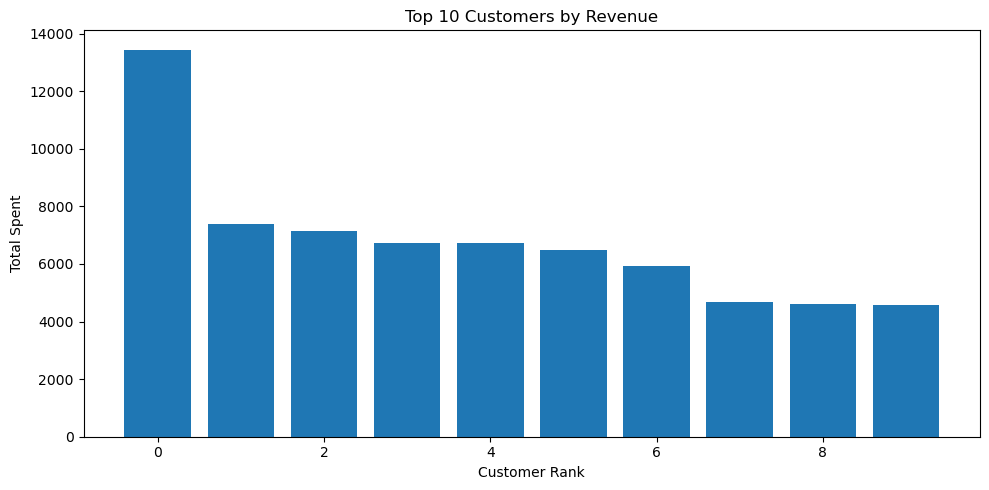

In [20]:
# Plot for top 10 customers by revenue
plt.figure(figsize=(10,5))
plt.bar(range(len(top_customers)), top_customers['total_spent'])
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer Rank')
plt.ylabel('Total Spent')
plt.tight_layout()
plt.show()

Business Insight: Revenue is concentrated among a small group of high-spending customers, with the top customer spending nearly twice as much as the next. This indicates the presence of a high-value segment, making retention and personalized engagement strategies particularly important.

## Insights & Findings

**Revenue Trend**
- Monthly revenue shows clear seasonality, with a major peak in November 2017 (\$1.01M), likely driven by holiday promotions and Black Friday activity.
- Revenue concentration in Q4 suggests marketing effectiveness during promotional periods.

**Customer Behavior**
- Average Order Value (AOV) of \$137.75 indicates healthy basket size.
- Repeat purchase rate is only 3.12%, which is relatively low for e-commerce and signals an opportunity to improve customer retention strategies.

**Product Performance**
- Top-performing categories:
  1. Beauty & Health — \$1.26M
  2. Watches & Gifts — \$1.21M
  3. Bed, Bath & Table (Home Textiles) — \$1.04M
- Revenue is heavily concentrated in lifestyle and home-related products.

**Business Opportunities**
- Implement retention programs (email, loyalty, remarketing) to increase repeat purchases.
- Double down on high-performing categories.
- Investigate drivers behind November revenue spike and replicate successful campaigns.

## Business Recommendations

Based on the data analysis:

1. Customer retention should be the top priority given the low repeat purchase rate (3.12%).
2. Marketing efforts should be optimized around Q4 when demand is highest.
3. Inventory and promotions should focus on top-performing categories (beleza_saude, relogios_presentes, cama_mesa_banho).
4. Further analysis could explore customer segmentation and cohort retention.

This analysis demonstrates how data-driven insights can guide e-commerce growth strategy.